In [4]:
!pip install -q tensorflow matplotlib seaborn scikit-learn opencv-python-headless

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print('All libraries have been successfully loaded')
print(f'TensorFlow version: {tf.__version__}')

# Checking for GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU available: {gpus[0].name}')
else:
    print('No GPU - will run on CPU (slower)')


All libraries have been successfully loaded
TensorFlow version: 2.20.0
No GPU - will run on CPU (slower)


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
BASE_PATH = '/content/drive/MyDrive/accident_dataset'
ACCIDENT_PATH    = os.path.join(BASE_PATH, 'Accident')
NONACCIDENT_PATH = os.path.join(BASE_PATH, 'NonAccident')

SEVERITY_BASE  = os.path.join(BASE_PATH, 'Severity Score Dataset with Labels')
SEVERITY_1_PATH = os.path.join(SEVERITY_BASE, '1')   # Minor Impact
SEVERITY_2_PATH = os.path.join(SEVERITY_BASE, '2')   # Substantial Impact
SEVERITY_3_PATH = os.path.join(SEVERITY_BASE, '3')   # Critical Impact

# Checking for the presence of tracks
paths_to_check = {
    'Accident':          ACCIDENT_PATH,
    'NonAccident':       NONACCIDENT_PATH,
    'Severity 1 (Minor)':       SEVERITY_1_PATH,
    'Severity 2 (Substantial)': SEVERITY_2_PATH,
    'Severity 3 (Critical)':    SEVERITY_3_PATH,
}

print('Data path check:')
all_ok = True
for name, path in paths_to_check.items():
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f'  {name}: {count} image')
    else:
        print(f'{name}: The path does not exist → {path}')
        all_ok = False

if all_ok:
    print('\nAll path are available - ready to start')
else:
    print('\n In incomplete paths - make sure the data is correctly uploaded to Drive')

Data path check:
  Accident: 6191 image
  NonAccident: 15420 image
  Severity 1 (Minor): 1874 image
  Severity 2 (Substantial): 2100 image
  Severity 3 (Critical): 2217 image

All path are available - ready to start


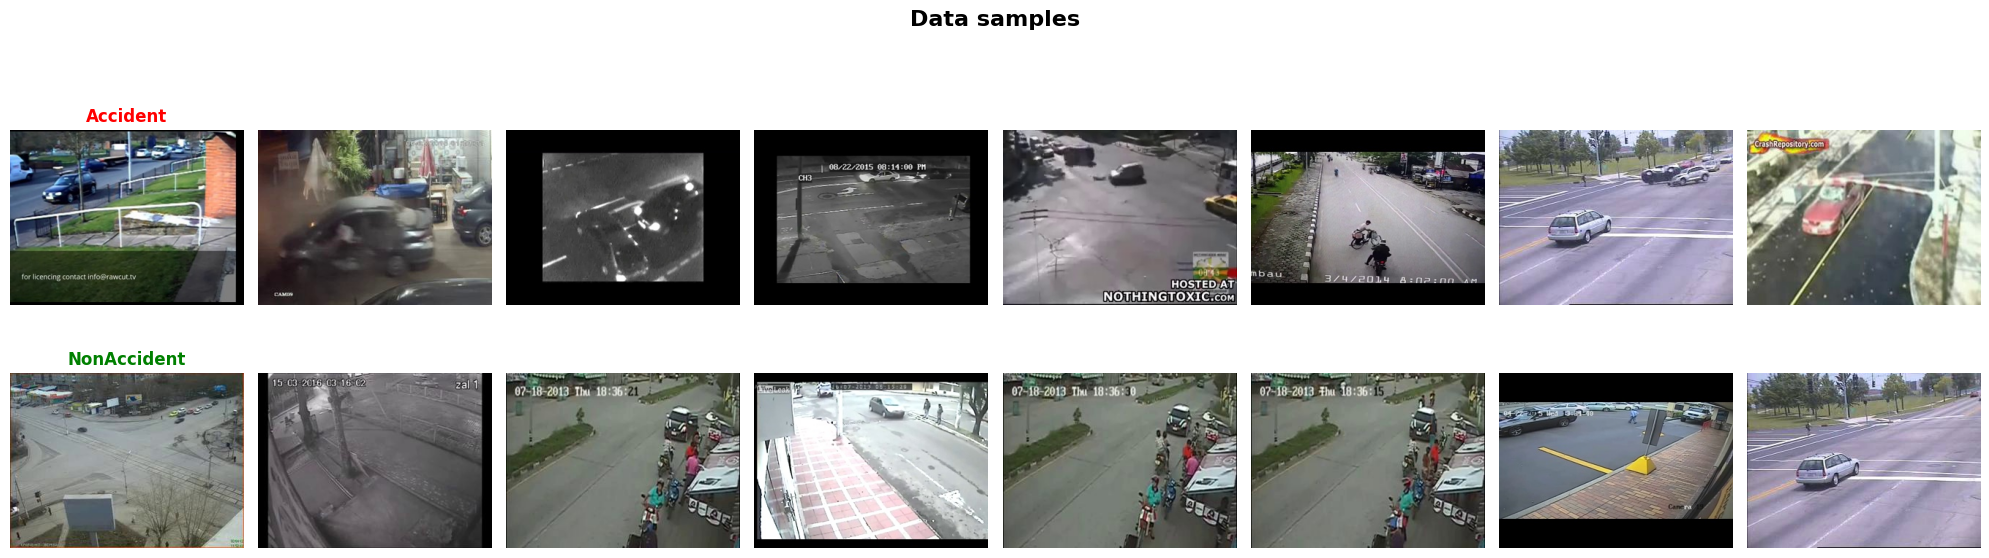

Number of photos Accident:    6191
Number of photos NonAccident: 15420


In [7]:
def load_and_show_samples(accident_path, nonaccident_path, n_samples=8):
    """
    Display random samples from both categories side by side
    """
    def get_image_files(folder, n):
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        chosen = np.random.choice(files, min(n, len(files)), replace=False)
        return [os.path.join(folder, f) for f in chosen]

    accident_imgs    = get_image_files(accident_path, n_samples)
    nonaccident_imgs = get_image_files(nonaccident_path, n_samples)

    fig, axes = plt.subplots(2, n_samples, figsize=(20, 6))
    fig.suptitle('Data samples', fontsize=16, fontweight='bold', y=1.02)

    for i, img_path in enumerate(accident_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Accident', color='red', fontweight='bold')

    for i, img_path in enumerate(nonaccident_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('NonAccident', color='green', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f'Number of photos Accident:    {len(os.listdir(accident_path))}')
    print(f'Number of photos NonAccident: {len(os.listdir(nonaccident_path))}')

load_and_show_samples(ACCIDENT_PATH, NONACCIDENT_PATH)

In [8]:
# Copying data from Drive to local Colab
import shutil

LOCAL_BASE = '/content/local_dataset'

# Accident  NonAccident
shutil.copytree(ACCIDENT_PATH,    f'{LOCAL_BASE}/accident',    dirs_exist_ok=True)
shutil.copytree(NONACCIDENT_PATH, f'{LOCAL_BASE}/nonaccident', dirs_exist_ok=True)

print(f"The data has been copied")
print(f"   Accident:    {len(os.listdir(LOCAL_BASE+'/accident'))} image")
print(f"   NonAccident: {len(os.listdir(LOCAL_BASE+'/nonaccident'))} image")

TRAIN_DIR = LOCAL_BASE

The data has been copied
   Accident:    6191 image
   NonAccident: 15420 image


In [9]:
import random

def keep_only_n_images(folder, n=2000):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if len(files) <= n:
        print(f"  {folder}: {len(files)} Image (less than  {n} -no need to reduce)")
        return
    to_delete = random.sample(files, len(files) - n)
    for f in to_delete:
        os.remove(os.path.join(folder, f))
    print(f"  {os.path.basename(folder)}: It shrank to {n} Image")

print("Reduce the data size for faster training")
keep_only_n_images(f'{LOCAL_BASE}/accident',    n=2000)
keep_only_n_images(f'{LOCAL_BASE}/nonaccident', n=2000)

Reduce the data size for faster training
  accident: It shrank to 2000 Image
  nonaccident: It shrank to 2000 Image


In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
import cv2

# Collect all the images with their labels

def collect_images(folder, label):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg','.jpeg','.png'))]
    return [(os.path.join(folder, f), label) for f in files]

all_data = collect_images(ACCIDENT_PATH, 0) + collect_images(NONACCIDENT_PATH, 1)
print(f"Total images: {len(all_data)}")
print(f"Accident:    {sum(1 for _,l in all_data if l==0)}")
print(f"NonAccident: {sum(1 for _,l in all_data if l==1)}")

#A true random split with stratify to maintain the ratio
paths  = [x[0] for x in all_data]
labels = [x[1] for x in all_data]

X_train, X_val, y_train, y_val = train_test_split(
    paths, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)}")
print(f"Train accidents: {sum(y_train)} | Val accidents: {sum(y_val)}")

# Custom Data Generator
class AccidentDataGenerator(Sequence):
    def __init__(self, paths, labels, batch_size=32, img_size=(224,224), augment=False, shuffle=True):
        self.paths      = paths
        self.labels     = labels
        self.batch_size = batch_size
        self.img_size   = img_size
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return len(self.paths) // self.batch_size

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, lbls = [], []
        for i in batch_idx:
            img = cv2.imread(self.paths[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.img_size)
            img = img / 255.0

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                if np.random.rand() > 0.5:
                    img = np.flipud(img)

            imgs.append(img)
            lbls.append(self.labels[i])

        return np.array(imgs), np.array(lbls)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def reset(self):
        self.indices = np.arange(len(self.paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = AccidentDataGenerator(X_train, y_train, batch_size=32, augment=True,  shuffle=True)
val_gen   = AccidentDataGenerator(X_val,   y_val,   batch_size=32, augment=False, shuffle=False)

print(" Generators Ready!")

# Class weights
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"Class weights: {class_weight_dict}")

Total images: 21611
Accident:    6191
NonAccident: 15420

Train: 17288 | Val: 4323
Train accidents: 12335 | Val accidents: 3085
 Generators Ready!
Class weights: {0: np.float64(1.7452049263072884), 1: np.float64(0.7007701661937576)}


In [11]:
def build_accident_classifier():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
model1 = build_accident_classifier()
model1.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
# Callbacks
callbacks_m1 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/best_accident_classifier.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('Starting training on the classification model (Accident vs NonAccident)')

from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"Class weights: {class_weight_dict}")
print(f"Class weights: {class_weight_dict}")

history1 = model1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_m1,
    class_weight=class_weight_dict,
    verbose=1
)

print('\n Training is over')

Starting training on the classification model (Accident vs NonAccident)
Class weights: {0: np.float64(1.7452049263072884), 1: np.float64(0.7007701661937576)}
Class weights: {0: np.float64(1.7452049263072884), 1: np.float64(0.7007701661937576)}
Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6701 - loss: 0.6125
Epoch 1: val_accuracy improved from None to 0.87894, saving model to /content/drive/MyDrive/best_accident_classifier.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_accident_classifier.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 1393s 3s/step - accuracy: 0.7328 - loss: 0.5194 - val_accuracy: 0.8789 - val_loss: 0.3450
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8216 - loss: 0.3886
Epoch 2: val_accuracy improved from 0.87894 to 0.91597, saving model to /content/drive/MyDrive/best_accident_classifier.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_accident_classifier.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 1232s 2s/st

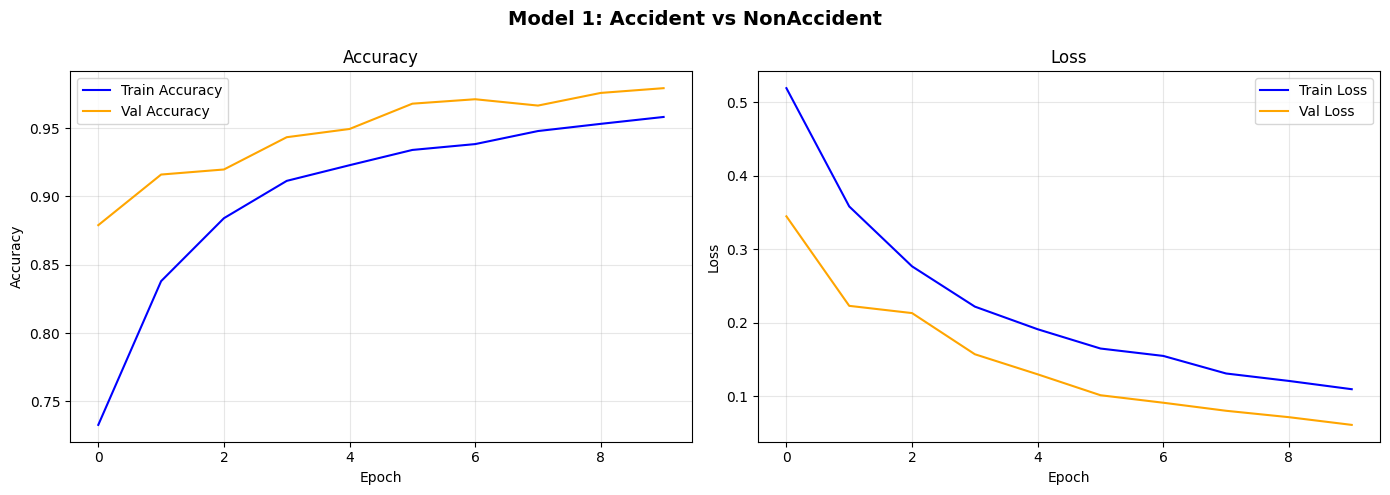

 Confusion Matrix


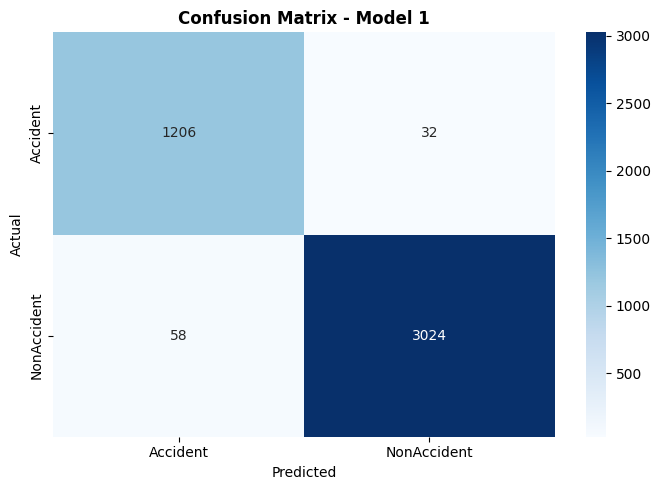

Classification Report:
              precision    recall  f1-score   support

    Accident       0.95      0.97      0.96      1238
 NonAccident       0.99      0.98      0.99      3082

    accuracy                           0.98      4320
   macro avg       0.97      0.98      0.97      4320
weighted avg       0.98      0.98      0.98      4320



In [17]:
def plot_training_history(history, title="Training History"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    ax1.plot(history.history["accuracy"],     label="Train Accuracy", color="blue")
    ax1.plot(history.history["val_accuracy"], label="Val Accuracy",   color="orange")
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history["loss"],     label="Train Loss", color="blue")
    ax2.plot(history.history["val_loss"], label="Val Loss",   color="orange")
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history1, "Model 1: Accident vs NonAccident")

# ── Confusion Matrix ──
print(" Confusion Matrix")


y_pred_list, y_true_list = [], []
for i in range(len(val_gen)):
    imgs, lbls = val_gen[i]
    preds = model1.predict(imgs, verbose=0)
    y_pred_list.extend((preds.flatten() > 0.5).astype(int).tolist())
    y_true_list.extend(lbls.astype(int).tolist())

y_pred_m1 = np.array(y_pred_list)
y_true_m1 = np.array(y_true_list)

class_names = ["Accident", "NonAccident"]

cm = confusion_matrix(y_true_m1, y_pred_m1)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Model 1", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

print("Classification Report:")
print(classification_report(y_true_m1, y_pred_m1, target_names=class_names))

In [18]:
def collect_severity_images(folder, label):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith((".jpg",".jpeg",".png"))]
    return [(os.path.join(folder, f), label) for f in files]

sev_data = (collect_severity_images(SEVERITY_1_PATH, 0) +
            collect_severity_images(SEVERITY_2_PATH, 1) +
            collect_severity_images(SEVERITY_3_PATH, 2))

sev_paths  = [x[0] for x in sev_data]
sev_labels = [x[1] for x in sev_data]

print(f"Total severity images: {len(sev_data)}")
print(f"Minor (1):       {sev_labels.count(0)}")
print(f"Substantial (2): {sev_labels.count(1)}")
print(f"Critical (3):    {sev_labels.count(2)}")

# Stratified Split
X_sev_train, X_sev_val, y_sev_train, y_sev_val = train_test_split(
    sev_paths, sev_labels,
    test_size=0.2,
    random_state=42,
    stratify=sev_labels
)

print(f"Train: {len(X_sev_train)} | Val: {len(X_sev_val)}")

sev_train_gen = AccidentDataGenerator(X_sev_train, y_sev_train,
                                       batch_size=32, augment=True,  shuffle=True)
sev_val_gen   = AccidentDataGenerator(X_sev_val,   y_sev_val,
                                       batch_size=32, augment=False, shuffle=False)

# Class weights
sev_weights = compute_class_weight("balanced",
                                    classes=np.array([0, 1, 2]),
                                    y=y_sev_train)
sev_class_weight = {0: sev_weights[0], 1: sev_weights[1], 2: sev_weights[2]}
print(f"Severity class weights: {sev_class_weight}")
print("Generators ")

Total severity images: 6191
Minor (1):       1874
Substantial (2): 2100
Critical (3):    2217
Train: 4952 | Val: 1239
Severity class weights: {0: np.float64(1.101178563486769), 1: np.float64(0.9825396825396825), 2: np.float64(0.9310020680579056)}
Generators 


Starting training for the model Severity
Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7716 - loss: 0.5630 
Epoch 1: val_accuracy improved from None to 0.99918, saving model to /content/drive/MyDrive/best_severity_classifier.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_severity_classifier.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 2187s 14s/step - accuracy: 0.9020 - loss: 0.2736 - val_accuracy: 0.9992 - val_loss: 0.0246
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9978 - loss: 0.0277
Epoch 2: val_accuracy improved from 0.99918 to 1.00000, saving model to /content/drive/MyDrive/best_severity_classifier.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_severity_classifier.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.9982 - loss: 0.0232 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9985 - loss: 0.0133
Epoch 3: val_accuracy did not improve

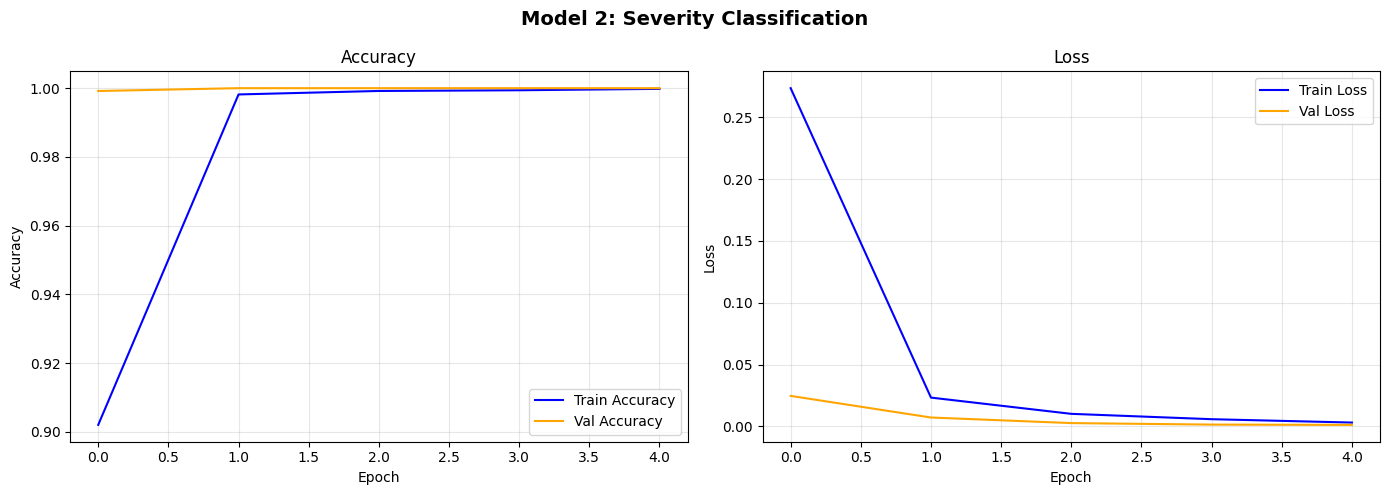

In [19]:
def build_severity_classifier():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model2 = build_severity_classifier()

callbacks_m2 = [
    EarlyStopping(monitor="val_accuracy", patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint("/content/drive/MyDrive/best_severity_classifier.keras",
                    monitor="val_accuracy", save_best_only=True, verbose=1)
]

print("Starting training for the model Severity")


history2 = model2.fit(
    sev_train_gen,
    validation_data=sev_val_gen,
    epochs=10,
    callbacks=callbacks_m2,
    class_weight=sev_class_weight,
    verbose=1
)

print("Training is over")
plot_training_history(history2, "Model 2: Severity Classification")

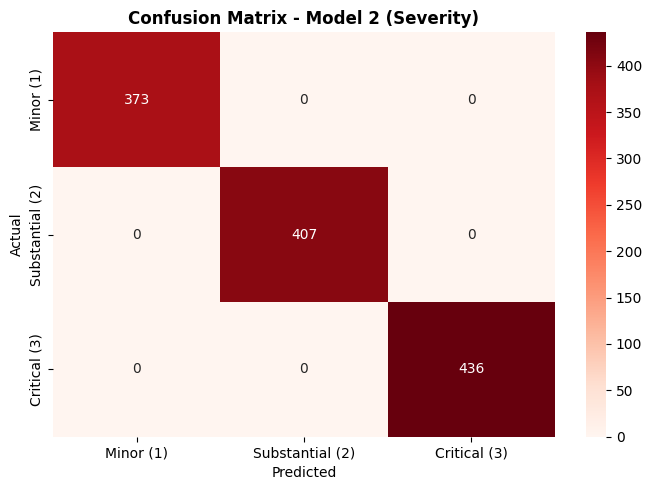

Severity Classification Report:
                 precision    recall  f1-score   support

      Minor (1)       1.00      1.00      1.00       373
Substantial (2)       1.00      1.00      1.00       407
   Critical (3)       1.00      1.00      1.00       436

       accuracy                           1.00      1216
      macro avg       1.00      1.00      1.00      1216
   weighted avg       1.00      1.00      1.00      1216



In [20]:
y_pred_sev_list, y_true_sev_list = [], []
for i in range(len(sev_val_gen)):
    imgs, lbls = sev_val_gen[i]
    preds = model2.predict(imgs, verbose=0)
    y_pred_sev_list.extend(np.argmax(preds, axis=1).tolist())
    y_true_sev_list.extend(lbls.astype(int).tolist())

y_pred_sev = np.array(y_pred_sev_list)
y_true_sev = np.array(y_true_sev_list)

severity_names = ["Minor (1)", "Substantial (2)", "Critical (3)"]

cm2 = confusion_matrix(y_true_sev, y_pred_sev)
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Reds",
            xticklabels=severity_names, yticklabels=severity_names)
plt.title("Confusion Matrix - Model 2 (Severity)", fontweight="bold")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

print("Severity Classification Report:")
print(classification_report(y_true_sev, y_pred_sev, target_names=severity_names))

In [21]:
import random

test_samples = []
for path, label in [(SEVERITY_1_PATH, 0), (SEVERITY_2_PATH, 1), (SEVERITY_3_PATH, 2)]:
    files = os.listdir(path)
    chosen = random.sample(files, 20)
    for f in chosen:
        test_samples.append((os.path.join(path, f), label))

random.shuffle(test_samples)

y_test_true, y_test_pred = [], []
for img_path, label in test_samples:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224)) / 255.0
    img_input = np.expand_dims(img, axis=0)

    pred = np.argmax(model2.predict(img_input, verbose=0))
    y_test_true.append(label)
    y_test_pred.append(pred)

print("Test results on brand new images:")
print(classification_report(y_test_true, y_test_pred,
      target_names=["Minor", "Substantial", "Critical"]))

Test results on brand new images:
              precision    recall  f1-score   support

       Minor       1.00      1.00      1.00        20
 Substantial       1.00      1.00      1.00        20
    Critical       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



 Model 1: Accident vs NonAccident


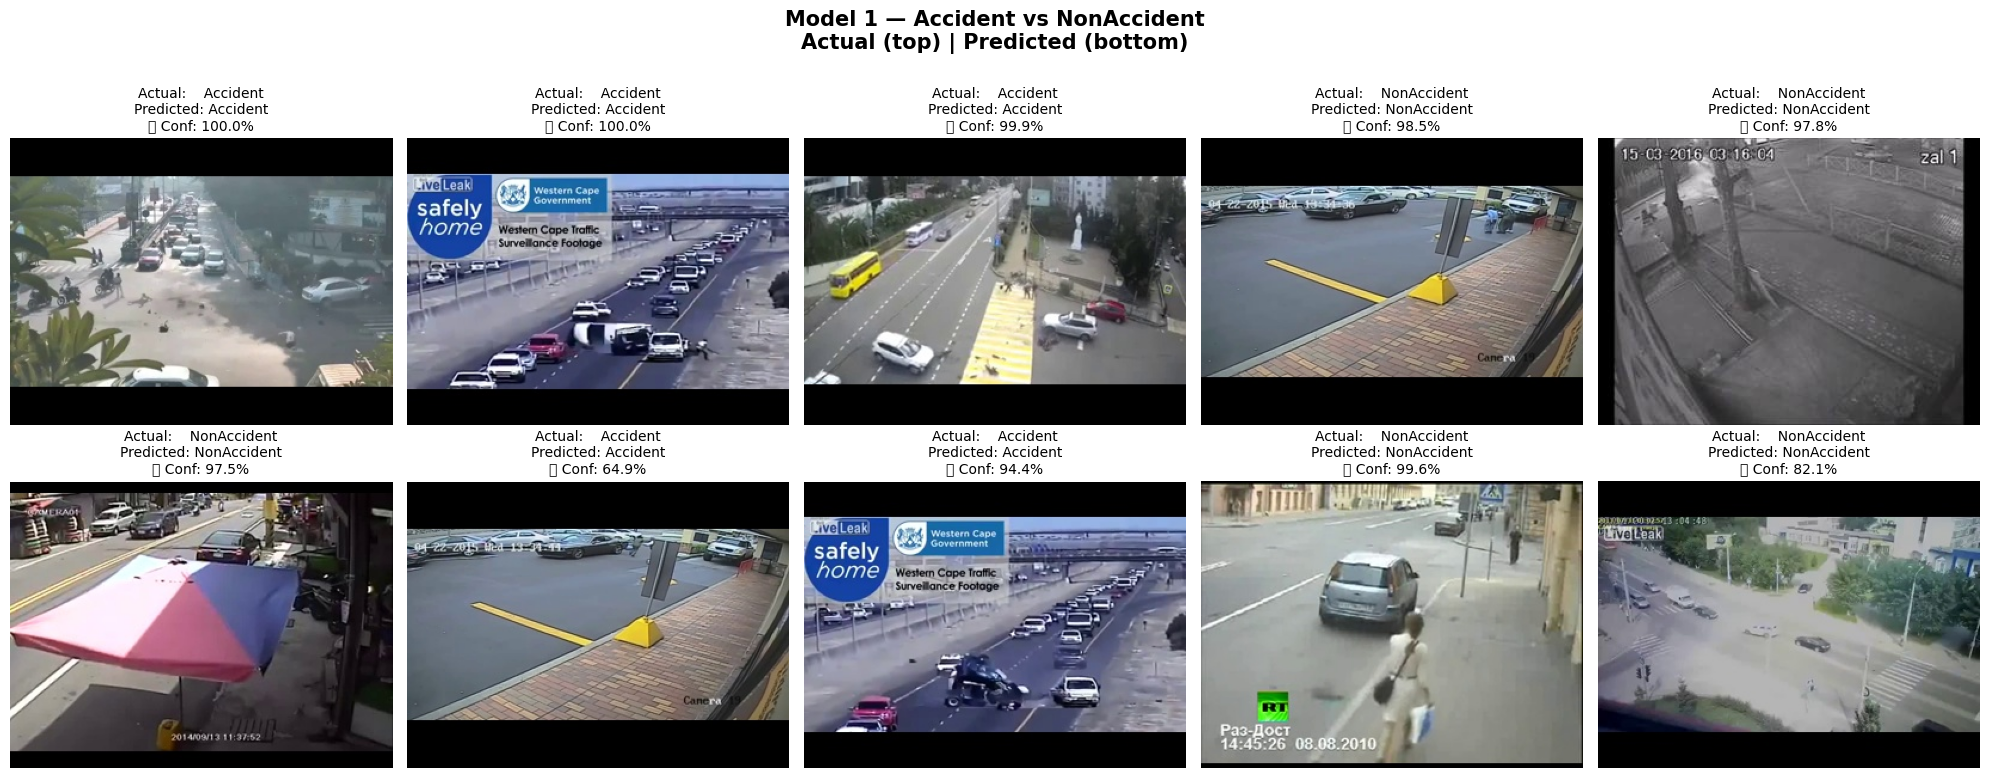


 Model 1 Score: 10/10 correct (100.0%)

 Model 2: Severity Classification


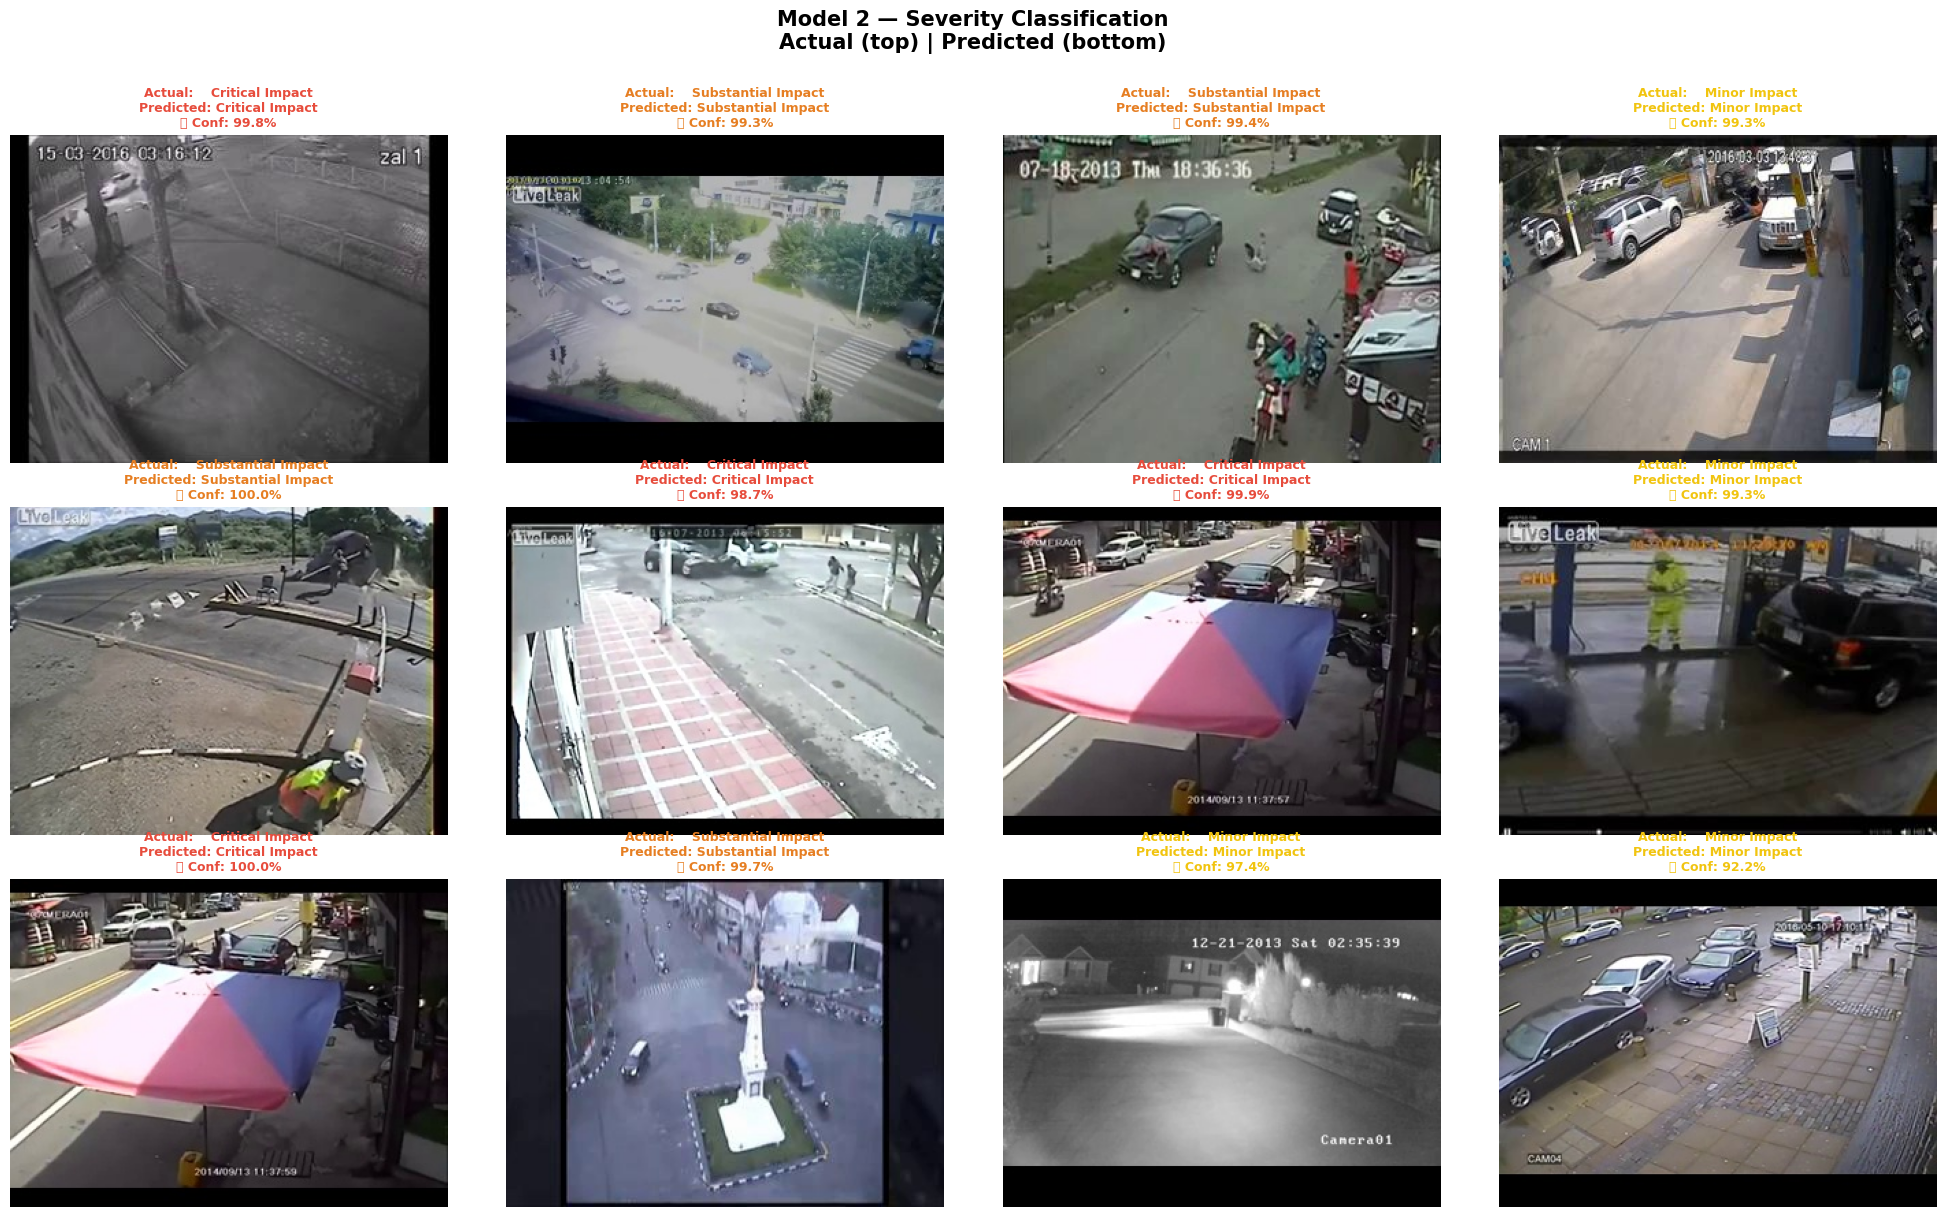


 Model 2 Score: 12/12 correct (100.0%)


In [25]:
import random
import math

def get_random_samples(n_per_class=4):

    samples = []

    # Accident vs NonAccident samples
    acc_files    = random.sample(os.listdir(ACCIDENT_PATH),    n_per_class)
    nonacc_files = random.sample(os.listdir(NONACCIDENT_PATH), n_per_class)

    for f in acc_files:
        samples.append((os.path.join(ACCIDENT_PATH, f), 'accident', 'model1'))
    for f in nonacc_files:
        samples.append((os.path.join(NONACCIDENT_PATH, f), 'nonaccident', 'model1'))

    # Severity samples
    sev1_files = random.sample(os.listdir(SEVERITY_1_PATH), n_per_class)
    sev2_files = random.sample(os.listdir(SEVERITY_2_PATH), n_per_class)
    sev3_files = random.sample(os.listdir(SEVERITY_3_PATH), n_per_class)

    for f in sev1_files:
        samples.append((os.path.join(SEVERITY_1_PATH, f), 'Minor Impact', 'model2'))
    for f in sev2_files:
        samples.append((os.path.join(SEVERITY_2_PATH, f), 'Substantial Impact', 'model2'))
    for f in sev3_files:
        samples.append((os.path.join(SEVERITY_3_PATH, f), 'Critical Impact', 'model2'))

    return samples



# Prediction function for a single image
def predict_single(img_path, which_model):
    """
    Returns: predicted_label (string), confidence (float)
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224)) / 255.0
    img_input = np.expand_dims(img, axis=0)

    if which_model == 'model1':
        prob = model1.predict(img_input, verbose=0)[0][0]
        if prob < 0.5:
            return 'accident',    1 - prob
        else:
            return 'nonaccident', prob

    else:  # model2
        probs   = model2.predict(img_input, verbose=0)[0]
        idx     = np.argmax(probs)
        labels  = {0: 'Minor Impact', 1: 'Substantial Impact', 2: 'Critical Impact'}
        return labels[idx], probs[idx]



# Model 1 Presentation: Accident vs Non-Accident

def show_model1_predictions(n_per_class=5):
    print(" Model 1: Accident vs NonAccident")
    print("=" * 50)

    acc_files    = random.sample(os.listdir(ACCIDENT_PATH),    n_per_class)
    nonacc_files = random.sample(os.listdir(NONACCIDENT_PATH), n_per_class)

    all_samples = (
        [(os.path.join(ACCIDENT_PATH, f),    'Accident')    for f in acc_files] +
        [(os.path.join(NONACCIDENT_PATH, f), 'NonAccident') for f in nonacc_files]
    )
    random.shuffle(all_samples)

    n_cols = 5
    n_rows = math.ceil(len(all_samples) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    fig.suptitle('Model 1 — Accident vs NonAccident\nActual (top) | Predicted (bottom)',
                 fontsize=15, fontweight='bold', y=1.01)

    axes = axes.flatten()
    correct = 0

    for i, (img_path, true_label) in enumerate(all_samples):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        pred_label, conf = predict_single(img_path, 'model1')

        pred_display = 'Accident' if pred_label == 'accident' else 'NonAccident'
        is_correct   = (pred_display == true_label)
        if is_correct:
            correct += 1

        border_color = '#2ecc71' if is_correct else '#e74c3c'

        axes[i].imshow(img)
        axes[i].axis('off')


        for spine in axes[i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)
            spine.set_visible(True)

        status_icon = '✅' if is_correct else '❌'
        axes[i].set_title(
            f"Actual:    {true_label}\n"
            f"Predicted: {pred_display}\n"
            f"{status_icon} Conf: {conf:.1%}",
            fontsize=10,
            color='black',
            pad=6
        )

    for j in range(len(all_samples), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f"\n Model 1 Score: {correct}/{len(all_samples)} correct ({correct/len(all_samples):.1%})")


# Model 2 Presentation: Severity Classification

def show_model2_predictions(n_per_class=4):
    print("\n Model 2: Severity Classification")
    print("=" * 50)

    sev_samples = (
        [(os.path.join(SEVERITY_1_PATH, f), 'Minor Impact')
         for f in random.sample(os.listdir(SEVERITY_1_PATH), n_per_class)] +
        [(os.path.join(SEVERITY_2_PATH, f), 'Substantial Impact')
         for f in random.sample(os.listdir(SEVERITY_2_PATH), n_per_class)] +
        [(os.path.join(SEVERITY_3_PATH, f), 'Critical Impact')
         for f in random.sample(os.listdir(SEVERITY_3_PATH), n_per_class)]
    )
    random.shuffle(sev_samples)

    severity_colors = {
        'Minor Impact':       '#f1c40f',
        'Substantial Impact': '#e67e22',
        'Critical Impact':    '#e74c3c',
    }

    n_cols = 4
    n_rows = math.ceil(len(sev_samples) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    fig.suptitle('Model 2 — Severity Classification\nActual (top) | Predicted (bottom)',
                 fontsize=15, fontweight='bold', y=1.01)

    axes = axes.flatten()
    correct = 0

    for i, (img_path, true_label) in enumerate(sev_samples):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        pred_label, conf = predict_single(img_path, 'model2')
        is_correct = (pred_label == true_label)
        if is_correct:
            correct += 1

        border_color = '#2ecc71' if is_correct else '#e74c3c'
        pred_color   = severity_colors.get(pred_label, 'black')
        status_icon  = '✅' if is_correct else '❌'

        axes[i].imshow(img)
        axes[i].axis('off')

        for spine in axes[i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)
            spine.set_visible(True)

        axes[i].set_title(
            f"Actual:    {true_label}\n"
            f"Predicted: {pred_label}\n"
            f"{status_icon} Conf: {conf:.1%}",
            fontsize=9,
            color=pred_color,
            fontweight='bold',
            pad=6
        )

    for j in range(len(sev_samples), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f"\n Model 2 Score: {correct}/{len(sev_samples)} correct ({correct/len(sev_samples):.1%})")


show_model1_predictions(n_per_class=5)
show_model2_predictions(n_per_class=4)

In [26]:
!pip install -q ultralytics
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")
print("YOLOv8 has been successfully loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 has been successfully loaded


ACCIDENT DETECTED
Accident Confidence : 99.9%
🔴 Severity           : Critical Impact (67.4%)
 Vehicles detected   : 5


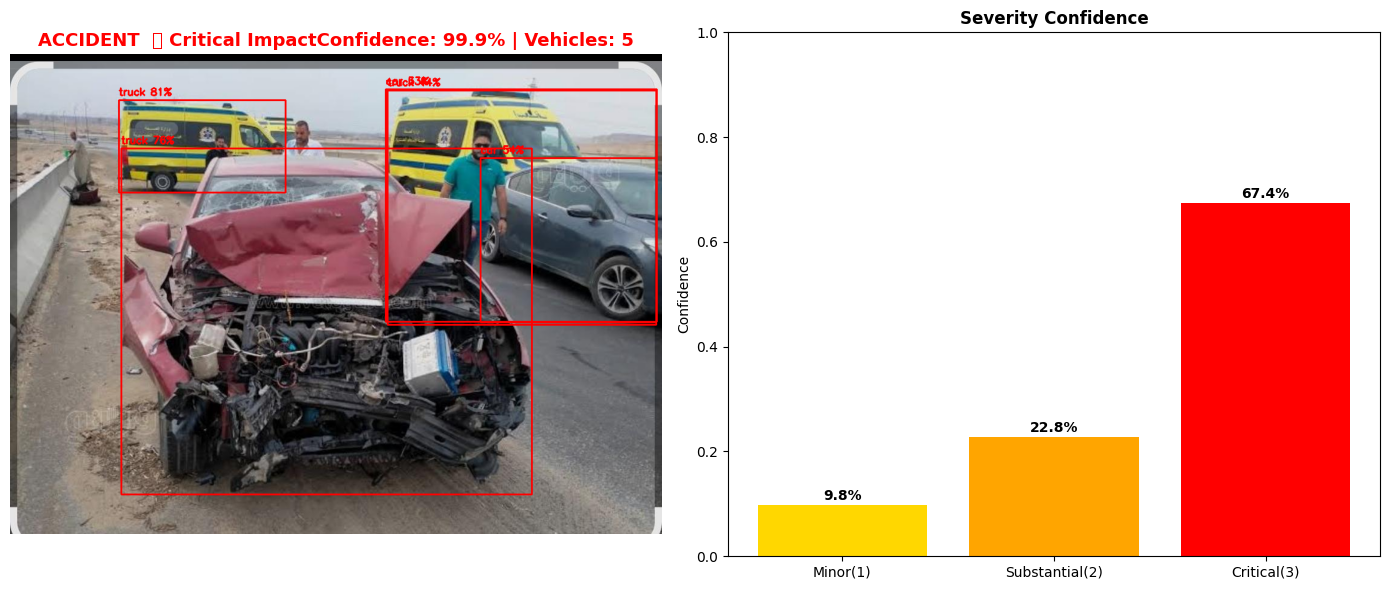

In [39]:
def detect_and_classify(image_path, yolo_model, accident_model, severity_model,
                         img_size=(224, 224)):

    SEVERITY_INFO = {
        0: ("Minor Impact",       "🟡"),
        1: ("Substantial Impact", "🟠"),
        2: ("Critical Impact",    "🔴"),
    }

    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f" Unable to open: {image_path}"); return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = yolo_model(img_rgb, verbose=False)[0]
    vehicle_classes = {2, 3, 5, 7}
    boxes = []
    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf   = float(box.conf[0])
        if cls_id in vehicle_classes and conf > 0.3:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            boxes.append({"bbox": (x1, y1, x2, y2),
                           "conf": conf,
                           "cls":  results.names[cls_id]})

    # Accident Classification
    img_input = np.expand_dims(cv2.resize(img_rgb, img_size) / 255.0, axis=0)
    pred_prob    = accident_model.predict(img_input, verbose=0)[0][0]
    is_accident  = pred_prob < 0.5
    acc_conf     = 1 - pred_prob if is_accident else pred_prob

    # Severity
    sev_probs, sev_label, sev_emoji = None, None, None
    if is_accident:
        sev_probs  = severity_model.predict(img_input, verbose=0)[0]
        sev_idx    = int(np.argmax(sev_probs))
        sev_label, sev_emoji = SEVERITY_INFO[sev_idx]

    #  Draw the picture with Bounding Boxes
    annotated = img_rgb.copy()
    box_color = (255, 0, 0) if is_accident else (0, 200, 0)
    for v in boxes:
        x1, y1, x2, y2 = v["bbox"]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), box_color, 2)
        cv2.putText(annotated, f"{v["cls"]} {v["conf"]:.0%}",
                    (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, box_color, 2)

    # Show the result
    if is_accident and sev_probs is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        ax1.imshow(annotated); ax1.axis("off")
        ax1.set_title(f"ACCIDENT  {sev_emoji} {sev_label}"
                      f"Confidence: {acc_conf:.1%} | Vehicles: {len(boxes)}",
                      color="red", fontsize=13, fontweight="bold")

        bars = ax2.bar(["Minor(1)", "Substantial(2)", "Critical(3)"],
                        sev_probs, color=["gold", "orange", "red"])
        ax2.set_title("Severity Confidence", fontweight="bold")
        ax2.set_ylabel("Confidence"); ax2.set_ylim(0, 1)
        for bar, p in zip(bars, sev_probs):
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f"{p:.1%}", ha="center", fontweight="bold")

        print(f"ACCIDENT DETECTED")
        print(f"Accident Confidence : {acc_conf:.1%}")
        print(f"{sev_emoji} Severity           : {sev_label} ({sev_probs[int(np.argmax(sev_probs))]:.1%})")
        print(f" Vehicles detected   : {len(boxes)}")
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(annotated); ax.axis("off")
        ax.set_title(f" No Accident | Confidence: {1-acc_conf:.1%} | Vehicles: {len(boxes)}",
                     color="green", fontsize=13, fontweight="bold")
        print(f"No Accident")
        print(f"   Confidence    : {1-acc_conf:.1%}")
        print(f"   Vehicles found: {len(boxes)}")

    plt.tight_layout(); plt.show()



TEST_IMAGE = "/content/WhatsApp Image 2026-05-07 at 1.02.56 AM.jpeg"

detect_and_classify(
    image_path     = TEST_IMAGE,
    yolo_model     = yolo_model,
    accident_model = model1,
    severity_model = model2
)